# Basic System

This notebook provides code for implementing a very simple machine learning system for named entity recognition.
It uses logistic regression and one feature (the token itself).
Links to information about the packages are provided. Your job is to document the code and use it to train a system. You can then use your evaluation code to provide the first basic evaluation of your system.

*Note:* In the next assignment, you can use this as a basis to experiment with more features and more machine learning methods.

### About this Notebook:
- The notebook is structured similarly to the assignment pdf. Each question contains suggestions to help guide you, but remember to follow the requirements in the PDF for your final answers.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
import pandas as pd
import sys
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
import gensim
import csv
import numpy as np
import sklearn
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import utils
import ner_machine_learning
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2.1. Load and inspect the data
**Suggestions:**
 - Download the following files form from canvas ,and place them in the folder "`./data/conll2003`":
   - `conll2003.train.conll`, `conll2003.test.conll`, `conll2003.dev.conll`


In [9]:
def extract_features(inputfile):
    """Takes as input the path to a conll file and returns a list of dictionaries
    with features for each token. The features include the token itself, the POS tag,
    the syntactic feature, the capitalization type ('uppercase', 'lowercase', 
    'first_letter_capitalization', or 'other'), and the previous and next tokens.

    The function processes the conll file and extracts the following features for each token:
        - token: the token itself
        - pos: the POS tag of the token
        - syntax: the syntactic feature of the token
        - capitalization: the capitalization pattern of the token ('uppercase', 'lowercase', 
          'first_letter_capitalization', or 'other')
        - prev_token: the previous token (or "START!!" if it is the first token in the sentence)
        - next_token: the next token (or "END!!" if it is the last token in the sentence)"""   
    data = []
    with open(inputfile, 'r', encoding='utf8') as infile:
        lines = infile.readlines()
        for line_index, line in enumerate(lines):
            components = line.rstrip('\n').split()
            if len(components) > 0:
                token = components[0] # token itself
                pos = components[1] # pos tag
                syn = components[2] # syntax
                if token.isupper(): #capitalization pattern
                    capitalization = 'uppercase'
                elif token.islower():
                    capitalization = 'lowercase'
                elif token.istitle():
                    capitalization = 'first_letter_capitalization'
                else:
                    capitalization = 'other'                
                if line_index > 0:  # if previous line
                    prev_line = lines[line_index-1].rstrip('\n')  # get previous line
                    if prev_line:  # if empty
                        prev_token = prev_line.split()[0] # get previous token
                    else:
                        prev_token = "START!!"  # start of sentence
                else:
                    prev_token = "START!!"  # start of sentence
                if line_index < len(lines) - 1:  # if next line
                    next_line = lines[line_index+1].rstrip('\n')  # get next line
                    if next_line:  # if empty
                        next_token = next_line.split()[0]  # get next token
                    else:
                        next_token = "END!!"  # end of sentence
                else:
                    next_token = "END!!"  # end of sentence
                feature_dict = {'token': token, 'pos': pos, 'syntax': syn, 
                                'capitalization': capitalization, 'prev_token': prev_token, 
                                'next_token': next_token}
                data.append(feature_dict)
                
    return data

In [10]:
def extract_dict_with_gold(inputfile):
    """Takes as input the path to a conll file and returns a list of dictionaries
    with features for each token. The features include the token itself, the POS tag,
    the syntactic feature, the capitalization type ('uppercase', 'lowercase', 
    'first_letter_capitalization', or 'other'), the previous and next tokens, and the gold NER label.

    The function processes the conll file and extracts the following features for each token:
        - token: the token itself
        - pos: the POS tag of the token
        - syntax: the syntactic feature of the token
        - capitalization: the capitalization pattern of the token ('uppercase', 'lowercase', 
          'first_letter_capitalization', or 'other')
        - prev_token: the previous token (or "START!!" if it is the first token in the sentence)
        - next_token: the next token (or "END!!" if it is the last token in the sentence)
        - gold_label: the NER gold label"""   
    data = []
    with open(inputfile, 'r', encoding='utf8') as infile:
        lines = infile.readlines()
        for line_index, line in enumerate(lines):
            components = line.rstrip('\n').split()
            if len(components) > 0:
                token = components[0] # token itself
                pos = components[1] # pos tag
                syn = components[2] # syntax
                gold =  components[-1] # gold label
                if token.isupper(): #capitalization pattern
                    capitalization = 'uppercase'
                elif token.islower():
                    capitalization = 'lowercase'
                elif token.istitle():
                    capitalization = 'first_letter_capitalization'
                else:
                    capitalization = 'other'                
                if line_index > 0:  # if previous line
                    prev_line = lines[line_index-1].rstrip('\n')  # get previous line
                    if prev_line:  # if empty
                        prev_token = prev_line.split()[0] # get previous token
                    else:
                        prev_token = "START!!"  # start of sentence
                else:
                    prev_token = "START!!"  # start of sentence
                if line_index < len(lines) - 1:  # if next line
                    next_line = lines[line_index+1].rstrip('\n')  # get next line
                    if next_line:  # if empty
                        next_token = next_line.split()[0]  # get next token
                    else:
                        next_token = "END!!"  # end of sentence
                else:
                    next_token = "END!!"  # end of sentence
                feature_dict = {'token': token, 'pos': pos, 'syntax': syn, 
                                'capitalization': capitalization, 
                                'prev_token': prev_token, 
                                'next_token': next_token,
                                'gold_label': gold}
                data.append(feature_dict)
                
    return data

In [11]:
def write_features_to_conll(train_features, outputfile):
    '''Takes dict with features and writes them to a new conll file. Each dictionary is represented by
    a new line and each line contains the features of the dictionary in separate columns separated by tab.'''
    with open(outputfile, 'w', encoding='utf8') as outfile:
        for feature_dict in train_features:
            token = feature_dict['token']
            pos = feature_dict['pos']
            syntax = feature_dict['syntax']
            capitalization = feature_dict['capitalization']
            gold = feature_dict['gold_label']
            prev_token = feature_dict['prev_token']
            next_token = feature_dict['next_token']
            line = f"{token}\t{pos}\t{syntax}\t{prev_token}\t{next_token}\t{capitalization}\t{gold}\n"
            outfile.write(line)

        outfile.write("\n")

In [53]:
data_folder = "../../data/conll2003/"

train_file = data_folder + "conll2003.train.conll"
test_file = data_folder + "conll2003.test.conll"
dev_file = data_folder + "conll2003.dev.conll"

# "../../data/conll2003/conll2003.dev.conll"

In [13]:
train_data = extract_features(train_file)
test_data = extract_features(test_file)
dev_data = extract_features(dev_file)

In [14]:
train_features = extract_dict_with_gold(train_file)
write_features_to_conll(train_features, 'all_train.conll')

In [15]:
dev_features = extract_dict_with_gold(dev_file)
write_features_to_conll(dev_features, 'all_dev.conll')

In [16]:
test_features = extract_dict_with_gold(test_file)
write_features_to_conll(test_features, 'all_test.conll')

In [17]:
train_targets = []
for dic in train_features:
    target = dic['gold_label']
    train_targets.append(target)

dev_targets = []
for dic in dev_features:
    target = dic['gold_label']
    dev_targets.append(target)

test_targets = []
for dic in test_features:
    target = dic['gold_label']
    test_targets.append(target)

In [18]:
all_features = ['token', 'pos', 'syntax', 'capitalization', 'prev_token', 'next_token']

In [19]:
print(train_data[:1])

[{'token': 'EU', 'pos': 'NNP', 'syntax': 'B-NP', 'capitalization': 'uppercase', 'prev_token': 'START!!', 'next_token': 'rejects'}]


## 2.2. Data analysis: feature and label distributions
**Suggestions:**

- Inspect which unique NER labels there are and plot their distribution (tip: look into the `Counter()`)
- Evaluate the samples per class to answer the questions in the pdf

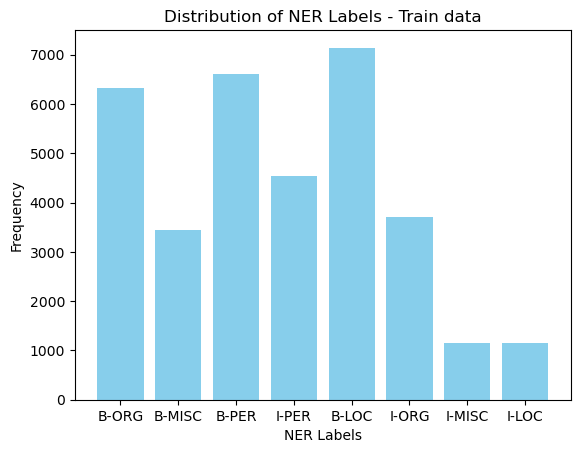

B-ORG: 6321
B-MISC: 3438
B-PER: 6600
I-PER: 4528
B-LOC: 7140
I-ORG: 3704
I-MISC: 1155
I-LOC: 1157


In [21]:
ner_train_labels = []
for dic in train_features:
    gold = dic['gold_label']
    if gold != 'O':
        ner_train_labels.append(gold)
train_label_counts = Counter(ner_train_labels)
plt.bar(train_label_counts.keys(), train_label_counts.values(), color='skyblue')
plt.xlabel("NER Labels")
plt.ylabel("Frequency")
plt.title("Distribution of NER Labels - Train data")
plt.show()

for label, count in train_label_counts.items():
    print(f"{label}: {count}")

In [22]:
# Most common words in each category

train_per_list = []
train_loc_list = []
train_org_list = []
train_misc_list = []

for dic in train_features:
    if 'PER' in dic['gold_label']:
        train_per_list.append(dic)
    if 'LOC' in dic['gold_label']:
        train_loc_list.append(dic)
    if 'ORG' in dic['gold_label']:
        train_org_list.append(dic)
    if 'MISC' in dic['gold_label']:
        train_misc_list.append(dic)


train_per_common_words = utils.most_common_words(train_per_list)
print('Most common persons: ', train_per_common_words)

train_loc_common_words = utils.most_common_words(train_loc_list)
print('Most common locations: ', train_loc_common_words)

train_org_common_words = utils.most_common_words(train_org_list)
print('Most common orgs: ', train_org_common_words)

train_misc_common_words = utils.most_common_words(train_misc_list)
print('Most common miscellaneous entities: ', train_misc_common_words)

Most common persons:  [('Clinton', 93), ('Mark', 58), ('Michael', 55), ('Paul', 51), ('John', 50), ('David', 50), ('Ahmed', 49), ('Arafat', 47), ('Martin', 47), ('Yeltsin', 47), ('M.', 46), ('Dole', 44), ('Lebed', 42), ('Akram', 37), ('Dutroux', 36), ('Wasim', 34), ('Thomas', 34), ('A.', 32), ('Peter', 31), ('Robert', 29)]
Most common locations:  [('U.S.', 309), ('Germany', 142), ('Britain', 133), ('Australia', 130), ('England', 124), ('France', 122), ('Spain', 110), ('Italy', 98), ('New', 95), ('LONDON', 93), ('China', 91), ('Russia', 88), ('Japan', 87), ('Pakistan', 85), ('Sweden', 81), ('South', 76), ('NEW', 73), ('Belgium', 71), ('India', 71), ('Iraq', 68)]
Most common orgs:  [('of', 104), ('Reuters', 79), ('Newsroom', 70), ('Inc', 61), ('St', 52), ('Party', 49), ('New', 49), ('Corp', 49), ('National', 48), ('United', 48), ('and', 46), ('Commission', 45), ('Bank', 43), ('Union', 40), ('U.N.', 40), ('Co', 38), ("'s", 34), ('Ajax', 34), ('Sydney', 34), ('York', 33)]
Most common misce

In [23]:
#Most common syntactic category

train_pos_list_per = utils.most_common_pos(train_per_list)
print('Most common POS in person list: ', train_pos_list_per)
train_pos_list_loc = utils.most_common_pos(train_loc_list)
print('Most common POS in location list: ', train_pos_list_loc)
train_pos_list_org = utils.most_common_pos(train_org_list)
print('Most common POS in org list: ', train_pos_list_org)
train_pos_list_misc = utils.most_common_pos(train_misc_list)
print('Most common POS in miscellaneous entity list: ', train_pos_list_misc)

Most common POS in person list:  [('NNP', 10512), ('NN', 191), ('JJ', 95), ('NNPS', 86), ('NNS', 63), ('FW', 34), ('RB', 28), ('JJR', 19), ('VB', 19), ('VBG', 17), ('VBZ', 13), ('VBN', 9), ('DT', 7), ('VBD', 6), ('UH', 6), ('IN', 5), ('CD', 5), ('TO', 2), ('JJS', 2), ('MD', 2)]
Most common POS in location list:  [('NNP', 7660), ('NN', 161), ('JJ', 110), ('NNPS', 65), ('RB', 39), ('VB', 37), ('NNS', 35), ('IN', 30), ('VBG', 29), ('VBN', 28), ('TO', 27), ('DT', 25), ('VBD', 8), ('JJR', 6), ('POS', 4), ('VBZ', 4), ('.', 4), ('CC', 3), ('WDT', 3), ('CD', 3)]
Most common POS in org list:  [('NNP', 8355), ('NN', 368), ('NNPS', 290), ('JJ', 183), ('NNS', 169), ('IN', 148), ('VB', 70), ('CC', 69), ('VBG', 57), ('POS', 40), ('DT', 38), ('RB', 31), ('FW', 30), ('CD', 24), ('VBN', 18), ('VBZ', 16), ('TO', 15), ('SYM', 15), (',', 13), ('UH', 11)]
Most common POS in miscellaneous entity list:  [('NNP', 2347), ('JJ', 1558), ('NNPS', 186), ('NN', 116), ('NNS', 97), ('CD', 76), ('$', 65), ('IN', 35), 

In [24]:
# Finding token length
avg_per, max_per, min_per = utils.analyze_token_length(train_per_list)
print(f"PERSON --> Average token length: {avg_per:.2f}, Max token length: {max_per}, Min token length: {min_per}")

avg_loc, max_loc, min_loc = utils.analyze_token_length(train_loc_list)
print(f"LOCATION --> Average token length: {avg_loc:.2f}, Max token length: {max_loc}, Min token length: {min_loc}")

avg_org, max_org, min_org = utils.analyze_token_length(train_org_list)
print(f"ORGANIZATION --> Average token length: {avg_org:.2f}, Max token length: {max_org}, Min token length: {min_org}")

avg_misc, max_misc, min_misc = utils.analyze_token_length(train_misc_list)
print(f"MISCELLANEOUS ENTITY --> Average token length: {avg_misc:.2f}, Max token length: {max_misc}, Min token length: {min_misc}")

PERSON --> Average token length: 6.06, Max token length: 18, Min token length: 1
LOCATION --> Average token length: 6.26, Max token length: 27, Min token length: 1
ORGANIZATION --> Average token length: 6.28, Max token length: 18, Min token length: 1
MISCELLANEOUS ENTITY --> Average token length: 6.45, Max token length: 21, Min token length: 1


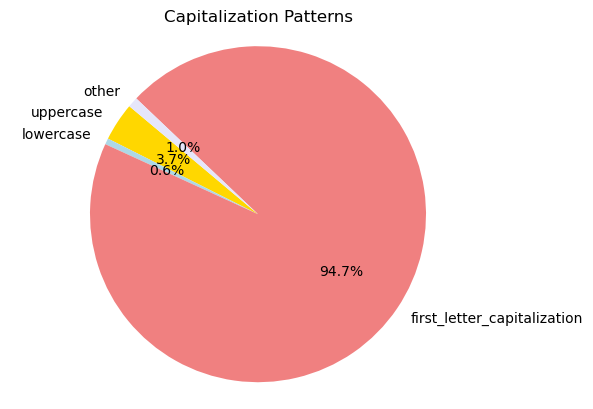

PERSON --> {'uppercase': 410, 'lowercase': 65, 'first_letter_capitalization': 10543, 'other': 110}


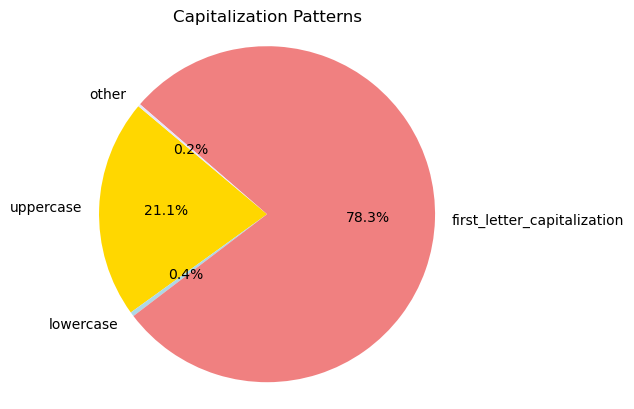

LOCATION --> {'uppercase': 1747, 'lowercase': 35, 'first_letter_capitalization': 6495, 'other': 20}


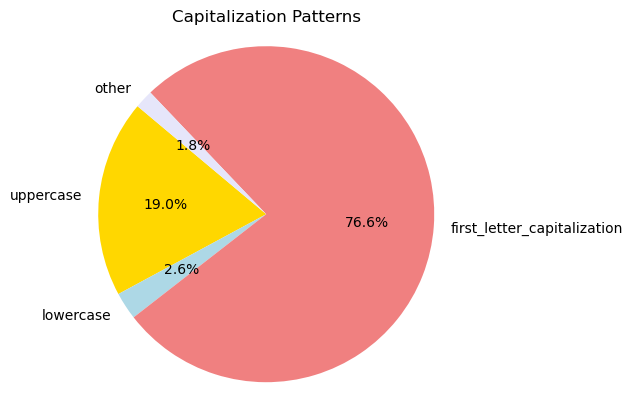

ORGANIZATION --> {'uppercase': 1904, 'lowercase': 265, 'first_letter_capitalization': 7678, 'other': 178}


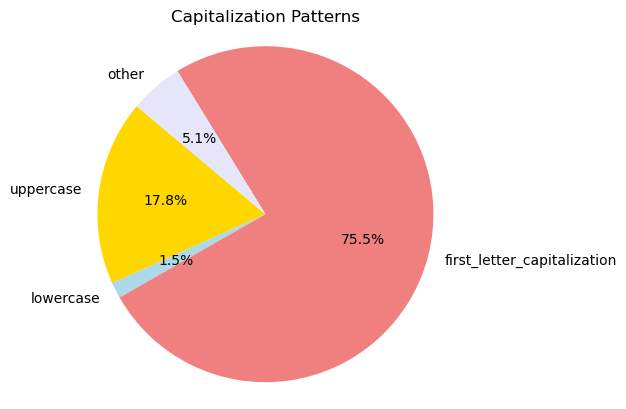

MISCELLANEOUS ENTITY --> {'uppercase': 819, 'lowercase': 71, 'first_letter_capitalization': 3468, 'other': 235}


In [25]:
# Finding capitalization patterns in each category

print("PERSON -->", utils.capitalization_patterns(train_per_list))
print("LOCATION -->", utils.capitalization_patterns(train_loc_list))
print("ORGANIZATION -->", utils.capitalization_patterns(train_org_list))
print("MISCELLANEOUS ENTITY -->", utils.capitalization_patterns(train_misc_list))

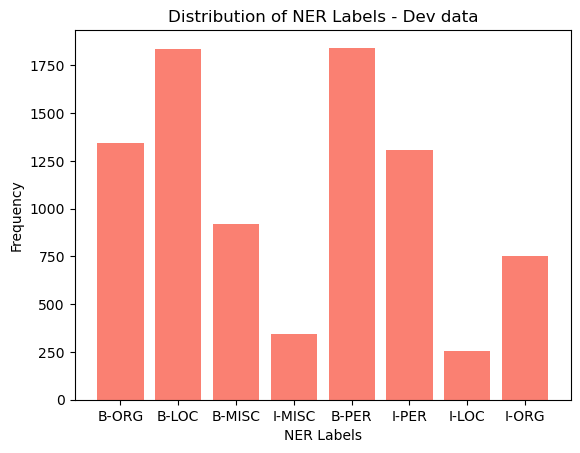

B-ORG: 1341
B-LOC: 1837
B-MISC: 922
I-MISC: 346
B-PER: 1842
I-PER: 1307
I-LOC: 257
I-ORG: 751


In [26]:
ner_dev_labels = []
for dic in dev_features:
    gold = dic['gold_label']
    if gold != 'O':
        ner_dev_labels.append(gold)
dev_label_counts = Counter(ner_dev_labels)
plt.bar(dev_label_counts.keys(), dev_label_counts.values(), color='salmon')
plt.xlabel("NER Labels")
plt.ylabel("Frequency")
plt.title("Distribution of NER Labels - Dev data")
plt.show()

for label, count in dev_label_counts.items():
    print(f"{label}: {count}")

In [30]:
dev_per_list = []
dev_loc_list = []
dev_org_list = []
dev_misc_list = []

for dic in dev_features:
    if 'PER' in dic['gold_label']:
        dev_per_list.append(dic)
    if 'LOC' in dic['gold_label']:
        dev_loc_list.append(dic)
    if 'ORG' in dic['gold_label']:
        dev_org_list.append(dic)
    if 'MISC' in dic['gold_label']:
        dev_misc_list.append(dic)


dev_per_common_words = utils.most_common_words(dev_per_list)
print('Most common persons: ', dev_per_common_words)

dev_loc_common_words = utils.most_common_words(dev_loc_list)
print('Most common locations: ', dev_loc_common_words)

dev_org_common_words = utils.most_common_words(dev_org_list)
print('Most common orgs: ', dev_org_common_words)

dev_misc_common_words = utils.most_common_words(dev_misc_list)
print('Most common miscellaneous entities: ', dev_misc_common_words)

Most common persons:  [('Lebed', 23), ('Wang', 23), ('Clinton', 20), ('Yeltsin', 19), ('Michael', 18), ('Peter', 14), ('Edberg', 14), ('Mark', 13), ('Paul', 13), ('David', 13), ('M.', 12), ('John', 12), ('Dole', 12), ('Suu', 12), ('Kyi', 12), ('Jansher', 11), ('Arafat', 11), ('Van', 11), ('Bernardin', 10), ('A.', 9)]
Most common locations:  [('U.S.', 114), ('Germany', 47), ('Russia', 45), ('France', 37), ('England', 32), ('Australia', 29), ('Iraq', 29), ('Israel', 29), ('Chechnya', 28), ('China', 27), ('Britain', 24), ('LONDON', 23), ('Italy', 21), ('South', 20), ('Belgium', 19), ('NEW', 18), ('YORK', 18), ('Jerusalem', 18), ('Moscow', 17), ('Spain', 17)]
Most common orgs:  [('of', 23), ('Reuters', 23), ('U.N.', 17), ('Party', 15), ('Department', 15), ('National', 13), ('&', 13), ('(', 13), (')', 13), ('Surrey', 12), ("'s", 12), ('York', 12), ('KDP', 12), ('Derbyshire', 11), ('New', 11), ('OSCE', 11), ('Pirelli', 11), ('Ruch', 11), ('Red', 10), ('Inc', 10)]
Most common miscellaneous en

In [33]:
# Finding most common POS tags

dev_pos_list_per = utils.most_common_pos(dev_per_list)
print('Most common POS in person list: ', dev_pos_list_per)
dev_pos_list_loc = utils.most_common_pos(dev_loc_list)
print('Most common POS in location list: ', dev_pos_list_loc)
dev_pos_list_org = utils.most_common_pos(dev_org_list)
print('Most common POS in org list: ', dev_pos_list_org)
dev_pos_list_misc = utils.most_common_pos(dev_misc_list)
print('Most common POS in miscellaneous entity list: ', dev_pos_list_misc)

Most common POS in person list:  [('NNP', 2960), ('NN', 50), ('JJ', 36), ('NNPS', 25), ('NNS', 19), ('FW', 14), ('VBN', 6), ('RB', 6), ('"', 4), ('IN', 4), ('(', 4), (')', 4), ('PRP', 4), ('VB', 3), ('UH', 3), ('VBG', 2), ('MD', 2), ('VBP', 1), ('DT', 1), ('CD', 1)]
Most common POS in location list:  [('NNP', 1930), ('NN', 42), ('JJ', 37), ('VB', 14), ('RB', 12), ('IN', 11), ('VBG', 11), ('NNPS', 10), ('DT', 7), ('NNS', 7), ('POS', 3), ('TO', 3), ('CD', 3), ('JJR', 1), ('VBD', 1), ('PRP', 1), ('VBN', 1)]
Most common POS in org list:  [('NNP', 1679), ('NN', 91), ('NNPS', 66), ('IN', 38), ('JJ', 35), ('VB', 32), ('NNS', 24), ('CC', 22), ('RB', 18), ('POS', 16), ('VBG', 13), ('(', 13), (')', 13), ('DT', 8), ('PRP', 3), ('VBZ', 3), ('JJS', 3), ('VBN', 3), ('TO', 2), ('CD', 2)]
Most common POS in miscellaneous entity list:  [('NNP', 622), ('JJ', 438), ('NNPS', 54), ('NN', 42), ('NNS', 21), ('CD', 21), ('IN', 19), ('DT', 13), ('RP', 13), ('$', 7), ('VB', 3), ('WDT', 2), ('FW', 2), ('VBP', 2)

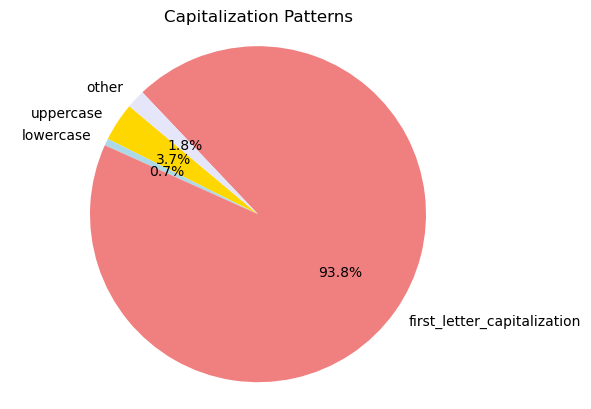

PERSON --> {'uppercase': 117, 'lowercase': 21, 'first_letter_capitalization': 2954, 'other': 57}


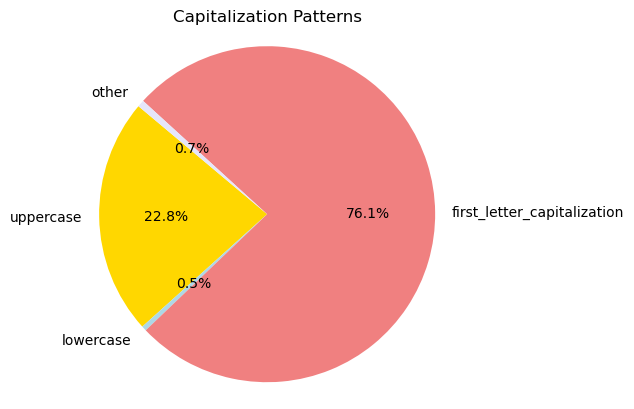

LOCATION --> {'uppercase': 477, 'lowercase': 10, 'first_letter_capitalization': 1593, 'other': 14}


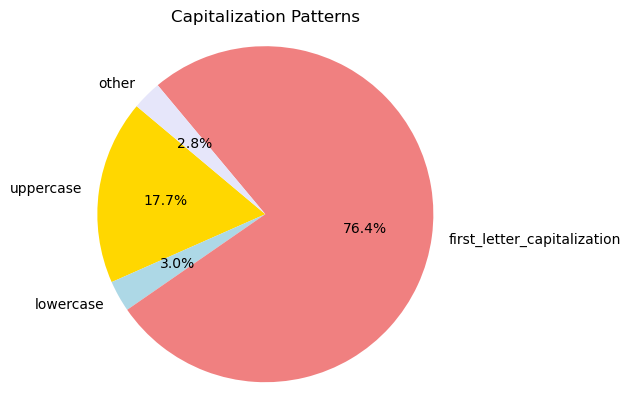

ORGANIZATION --> {'uppercase': 371, 'lowercase': 63, 'first_letter_capitalization': 1599, 'other': 59}


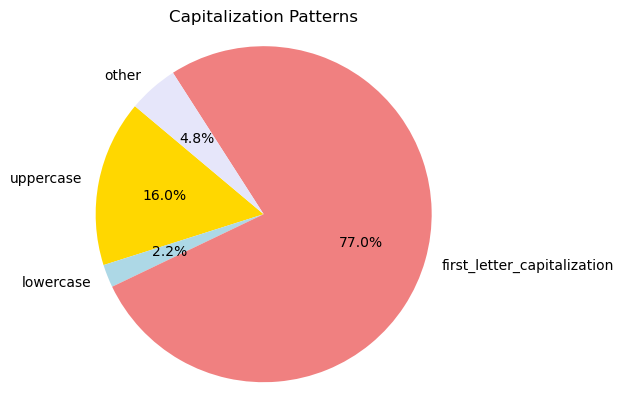

MISCELLANEOUS ENTITY --> {'uppercase': 203, 'lowercase': 28, 'first_letter_capitalization': 976, 'other': 61}


In [34]:
# Finding capitalization patterns in each category

print("PERSON -->", utils.capitalization_patterns(dev_per_list))
print("LOCATION -->", utils.capitalization_patterns(dev_loc_list))
print("ORGANIZATION -->", utils.capitalization_patterns(dev_org_list))
print("MISCELLANEOUS ENTITY -->", utils.capitalization_patterns(dev_misc_list))

In [36]:
# Find token length

dev_avg_per, dev_max_per, dev_min_per = utils.analyze_token_length(dev_per_list)
print(f"PERSON --> Average token length: {dev_avg_per:.2f}, Max token length: {dev_max_per}, Min token length: {dev_min_per}")

dev_avg_loc, dev_max_loc, dev_min_loc = utils.analyze_token_length(dev_loc_list)
print(f"LOCATION --> Average token length: {dev_avg_loc:.2f}, Max token length: {dev_max_loc}, Min token length: {dev_min_loc}")

dev_avg_org, dev_max_org, dev_min_org = utils.analyze_token_length(dev_org_list)
print(f"ORGANIZATION --> Average token length: {dev_avg_org:.2f}, Max token length: {dev_max_org}, Min token length: {dev_min_org}")

dev_avg_misc, dev_max_misc, dev_min_misc = utils.analyze_token_length(dev_misc_list)
print(f"MISCELLANEOUS ENTITY --> Average token length: {dev_avg_misc:.2f}, Max token length: {dev_max_misc}, Min token length: {dev_min_misc}")

PERSON --> Average token length: 6.05, Max token length: 18, Min token length: 1
LOCATION --> Average token length: 6.33, Max token length: 17, Min token length: 1
ORGANIZATION --> Average token length: 6.29, Max token length: 18, Min token length: 1
MISCELLANEOUS ENTITY --> Average token length: 6.23, Max token length: 18, Min token length: 1


## 2.3. Evaluation

**Suggestions:**
- Create a sample file with the ground_truth features and labels `sample_gt.conll` and a sample prediction file with the predictions `sample_pred.conll`.
- Create a function functions to calculate different metrics from two files: e.g. precision(), recall(), f-score(), confusion_matrix(). (Note you can use packages, e.g. `sklearn`)

In [29]:
# Creating the two files 

# with open('fake_files/sample_gt.conll', 'w') as file:
#         for token_dict, label in zip(train_data[:208], train_targets[:208]):
#             token = token_dict['token']
#             file.write(f"{token}\t{label}\n")
#         file.write("\n")

# with open('fake_files/sample_pred.conll', 'w') as file:
#         for token_dict, label in zip(train_data[:208], train_targets[:208]):
#             token = token_dict['token']
#             file.write(f"{token}\t{label}\n")
#         file.write("\n")

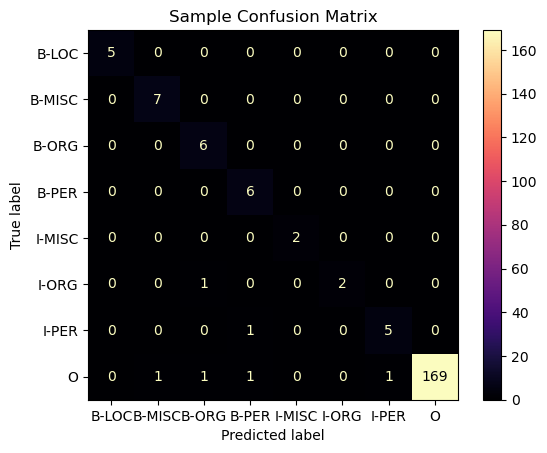

              precision    recall  f1-score   support

       B-LOC       1.00      1.00      1.00         5
      B-MISC       0.88      1.00      0.93         7
       B-ORG       0.75      1.00      0.86         6
       B-PER       0.75      1.00      0.86         6
      I-MISC       1.00      1.00      1.00         2
       I-ORG       1.00      0.67      0.80         3
       I-PER       0.83      0.83      0.83         6
           O       1.00      0.98      0.99       173

    accuracy                           0.97       208
   macro avg       0.90      0.93      0.91       208
weighted avg       0.98      0.97      0.97       208



In [71]:
print(utils.find_prec_recall_fscore_matrix('fake_files/sample_gt.conll', 'fake_files/sample_pred.conll'))

## 2.4. Train and evaluate basic NERC system
**Suggestions:**
- Train the Logistic regression classifier on your dataset and evaluate the performance on your various metrics.
- Transfer your code to a python file 

In [58]:
feature_to_index = {'Token': 0, 'Pos': 1, 'Chunklabel': 2, 'Prevtoken': 3, 
                    'Nexttoken': 4, 'Cap': 5, 'Gold': 6}

def extract_word_embedding(token, word_embedding_model):
    '''
    Function that returns the word embedding for a given token out of a distributional semantic model and a 300-dimension vector of 0s otherwise
    
    :param token: the token
    :param word_embedding_model: the distributional semantic model
    :type token: string
    :type word_embedding_model: gensim.models.keyedvectors.Word2VecKeyedVectors
    
    :returns a vector representation of the token
    '''
    if token in word_embedding_model:
        vector = word_embedding_model[token]
    else:
        vector = [0]*300
    return vector


def extract_feature_values(row, selected_features):
    '''
    Function that extracts feature value pairs from row
    
    :param row: row from conll file
    :param selected_features: list of selected features
    :type row: string
    :type selected_features: list of strings
    
    :returns: dictionary of feature value pairs
    '''
    feature_values = {}
    for feature_name in selected_features:
        r_index = feature_to_index.get(feature_name)
        feature_values[feature_name] = row[r_index]
        
    return feature_values
    
def create_vectorizer_traditional_features(feature_values):
    '''
    Function that creates vectorizer for set of feature values
    
    :param feature_values: list of dictionaries containing feature-value pairs
    :type feature_values: list of dictionairies (key and values are strings)
    
    :returns: vectorizer with feature values fitted
    '''
    vectorizer = DictVectorizer()
    vectorizer.fit(feature_values)
    
    return vectorizer
    
def combine_sparse_and_dense_features(dense_vectors, sparse_features):
    '''
    Function that takes sparse and dense feature representations and appends their vector representation
    
    :param dense_vectors: list of dense vector representations
    :param sparse_features: list of sparse vector representations
    :type dense_vector: list of arrays
    :type sparse_features: list of lists
    
    :returns: list of arrays in which sparse and dense vectors are concatenated
    '''
    
    combined_vectors = []
    sparse_vectors = np.array(sparse_features.toarray())
    
    for index, vector in enumerate(sparse_vectors):
        combined_vector = np.concatenate((vector,dense_vectors[index]))
        combined_vectors.append(combined_vector)
    return combined_vectors
    

def extract_traditional_features_and_embeddings_plus_gold_labels(conllfile, word_embedding_model, vectorizer=None):
    '''
    Function that extracts traditional features as well as embeddings and gold labels using word embeddings for current and preceding token
    
    :param conllfile: path to conll file
    :param word_embedding_model: a pretrained word embedding model
    :type conllfile: string
    :type word_embedding_model: gensim.models.keyedvectors.Word2VecKeyedVectors
    
    :return features: list of vector representation of tokens
    :return labels: list of gold labels
    '''
    labels = []
    dense_vectors = []
    traditional_features = []
    
    conllinput = open(conllfile, 'r')
    csvreader = csv.reader(conllinput, delimiter='\t',quotechar='|')
    for row in csvreader:
        if len(row) == 7:
            token_vector = extract_word_embedding(row[0], word_embedding_model)
            pt_vector = extract_word_embedding(row[3], word_embedding_model)
            nt_vector = extract_word_embedding(row[4], word_embedding_model)
            dense_vectors.append(np.concatenate((token_vector,pt_vector,nt_vector)))
            #mixing very sparse representations (for one-hot tokens) and dense representations is a bad idea
            #we thus only use other features with limited values
            other_features = extract_feature_values(row, ['Pos', 'Chunklabel', 'Cap'])
            traditional_features.append(other_features)
            #adding gold label to labels
            labels.append(row[-1])
            
    #create vector representation of traditional features
    if vectorizer is None:
        #creates vectorizer that provides mapping (only if not created earlier)
        vectorizer = create_vectorizer_traditional_features(traditional_features)
    sparse_features = vectorizer.transform(traditional_features)
    combined_vectors = combine_sparse_and_dense_features(dense_vectors, sparse_features)
    
    return combined_vectors, vectorizer, labels

def label_data_with_combined_features(testfile, classifier, vectorizer, word_embedding_model):
    '''
    Function that labels data with model using both sparse and dense features
    '''
    feature_vectors, vectorizer, goldlabels = extract_traditional_features_and_embeddings_plus_gold_labels(testfile, word_embedding_model, vectorizer)
    predictions = classifier.predict(feature_vectors)
    
    return predictions, goldlabels


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.feature_extraction import DictVectorizer
from scipy.stats import uniform
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC

def create_classifier(model_name='logreg', embedded=False, train_file=None):
    """
    Trains a classifier using specified features and labels. Supports logistic regression, Naive Bayes, 
    and SVM. Includes hyperparameter tuning for SVM using GridSearchCV or RandomizedSearchCV.

    Parameters: model_name ('logreg', 'NB', 'SVM'), embedded (bool), train_file.
    Returns a tuple containing the trained model and the vectorizer used for feature extraction
    (if embeddings-based training is not used). If embeddings-based training is used, 
    only the trained model is returned.
    """
    if embedded:
        model = LinearSVC(max_iter=2000)
        print("Extracting combined features for embeddings...")
        combined_vectors, vec, train_targets = extract_traditional_features_and_embeddings_plus_gold_labels(
            train_file, word_embedding_model)
        model.fit(combined_vectors, train_targets)
        return model, vec
        
    else:
        vec = DictVectorizer()
        train_features = extract_features(train_file)
        train_data = extract_dict_with_gold(train_file)
        train_targets = [dic['gold_label'] for dic in train_data]
        
        if model_name == 'logreg':
            model = LogisticRegression(max_iter=2000)
            features_vectorized = vec.fit_transform(train_features)
            model.fit(features_vectorized, train_targets)
            return model, vec

        elif model_name == 'NB':
            model = MultinomialNB()
            features_vectorized = vec.fit_transform(train_features)
            model.fit(features_vectorized, train_targets)
            return model, vec

        elif model_name == 'SVC':
            model = LinearSVC()
            features_vectorized = vec.fit_transform(train_features)
            param_grid = {
                'C': [0.01, 0.1, 1, 10, 100],
                'loss': ['hinge', 'squared_hinge'],
                'max_iter': [2000, 5000, 10000]
            }
            grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_macro')
            grid_search.fit(features_vectorized, train_targets)
            print(f"Best value of C: {grid_search.best_params_['C']}")
            print(f"Best value of loss: {grid_search.best_params_['loss']}")
            print(f"Best value of max_iter: {grid_search.best_params_['max_iter']}")
            model = grid_search.best_estimator_
            return model, vec

In [61]:
def classify_data(inputfile, outputfile, model=None, vec=None, embedded=False, 
                  language_model=None):
    """
    Classifies input data using a trained model and vectorizer, with optional feature extraction 
    using word embeddings. Saves the classification results to an output file.

    Parameters: inputfile, outputfile, model, vec, embedded (bool), 
    language_model (optional language model used for embeddings-based feature extraction)
        
    Returns None. The function saves the classification results to the specified output file.
    """
    if embedded:
        print("Extracting features for classification with embeddings...")
        feature_vectors, _, _ = extract_traditional_features_and_embeddings_plus_gold_labels(
            inputfile, word_embedding_model, vectorizer=vec)
        predictions = model.predict(feature_vectors)

    else:
        features = extract_features(inputfile)
        features = vec.transform(features)
        predictions = model.predict(features)

    outfile = open(outputfile, 'w')
    counter = 0
    for line in open(inputfile, 'r'):
        if len(line.rstrip('\n').split()) > 0:
            outfile.write(line.rstrip('\n') + '\t' + predictions[counter] + '\n')
            counter += 1
    outfile.close()

In [21]:
#embeddings svm
word_embedding_model = gensim.models.KeyedVectors.load_word2vec_format('../../models/GoogleNews-vectors-negative300.bin.gz', 
                                                                 binary=True)

Extracting combined features for embeddings...
Extracting features for classification with embeddings...
Printing results...


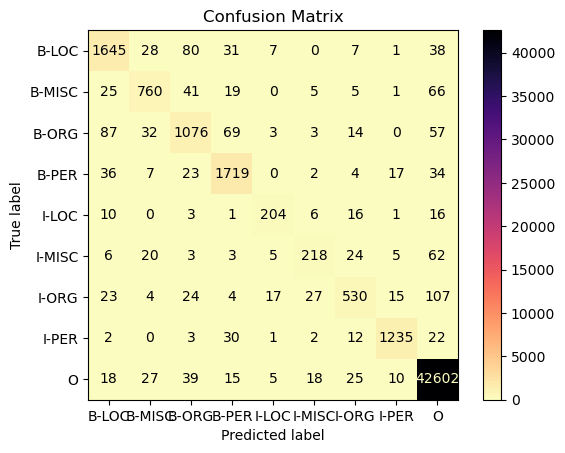

              precision    recall  f1-score   support

       B-LOC      0.888     0.895     0.892      1837
      B-MISC      0.866     0.824     0.844       922
       B-ORG      0.833     0.802     0.817      1341
       B-PER      0.909     0.933     0.921      1842
       I-LOC      0.843     0.794     0.818       257
      I-MISC      0.776     0.630     0.695       346
       I-ORG      0.832     0.706     0.764       751
       I-PER      0.961     0.945     0.953      1307
           O      0.991     0.996     0.993     42759

    accuracy                          0.973     51362
   macro avg      0.878     0.836     0.855     51362
weighted avg      0.972     0.973     0.973     51362



In [23]:
embeddings_model, vectorizer = create_classifier(embedded=True, train_file='all_train.conll') 
classify_data('all_dev.conll', 'emb_file.conll', model=embeddings_model, vec=vectorizer, 
              language_model=word_embedding_model, embedded=True)
print('Printing results...')
print(utils.metrics_and_matrix('emb_file.conll'))

In [36]:
#logistic regression model
logreg_model, logreg_vec = create_classifier(train_file='all_train.conll', model_name='logreg')
classify_data('../../data/conll2003/conll2003.dev.conll', 'logreg_file.conll', model=logreg_model, vec=logreg_vec)

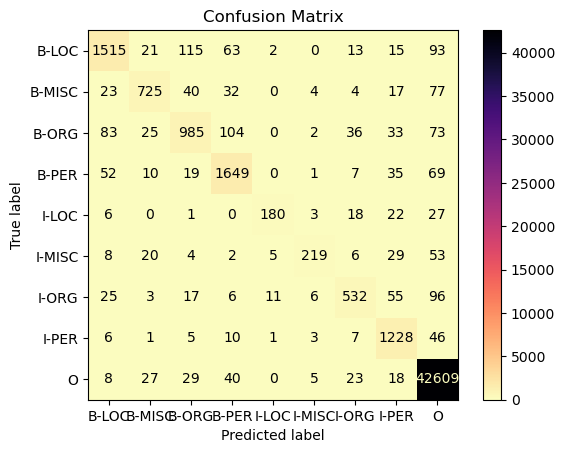

              precision    recall  f1-score   support

       B-LOC      0.878     0.825     0.850      1837
      B-MISC      0.871     0.786     0.827       922
       B-ORG      0.811     0.735     0.771      1341
       B-PER      0.865     0.895     0.880      1842
       I-LOC      0.905     0.700     0.789       257
      I-MISC      0.901     0.633     0.744       346
       I-ORG      0.824     0.708     0.762       751
       I-PER      0.846     0.940     0.890      1307
           O      0.988     0.996     0.992     42759

    accuracy                          0.967     51362
   macro avg      0.876     0.802     0.834     51362
weighted avg      0.966     0.967     0.966     51362



In [44]:
print(utils.metrics_and_matrix('logreg_file.conll'))

In [64]:
#LinearSVC before hyper-parameter tuning

vec = DictVectorizer()
features = extract_features(train_file)
train_data = extract_dict_with_gold(train_file)
train_targets = [dic['gold_label'] for dic in train_data]
features_vectorized = vec.fit_transform(features)
model = LinearSVC()
model.fit(features_vectorized, train_targets)
classify_data('../../data/conll2003/conll2003.dev.conll', 'svm_before.conll', model=model, vec=vec)

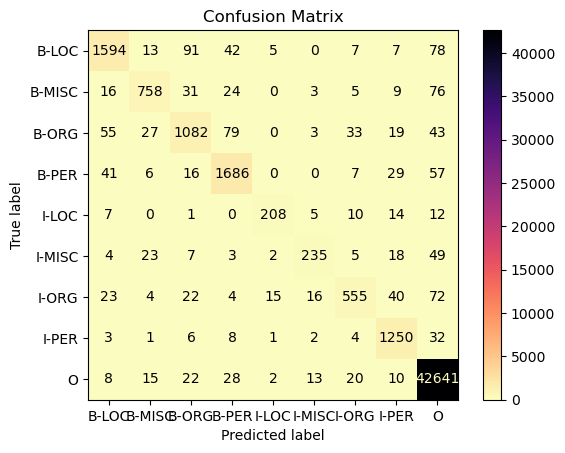

              precision    recall  f1-score   support

       B-LOC      0.910     0.868     0.889      1837
      B-MISC      0.895     0.822     0.857       922
       B-ORG      0.847     0.807     0.826      1341
       B-PER      0.900     0.915     0.907      1842
       I-LOC      0.893     0.809     0.849       257
      I-MISC      0.848     0.679     0.754       346
       I-ORG      0.859     0.739     0.795       751
       I-PER      0.895     0.956     0.925      1307
           O      0.990     0.997     0.994     42759

    accuracy                          0.974     51362
   macro avg      0.893     0.844     0.866     51362
weighted avg      0.973     0.974     0.973     51362



In [65]:
print(utils.metrics_and_matrix('svm_before.conll'))

In [57]:
#Naive Bayes
nb_model, nb_vec = create_classifier(train_file=train_file, model_name='NB') 
classify_data('../../data/conll2003/conll2003.dev.conll', 'nb_file.conll', model=nb_model, vec=nb_vec)

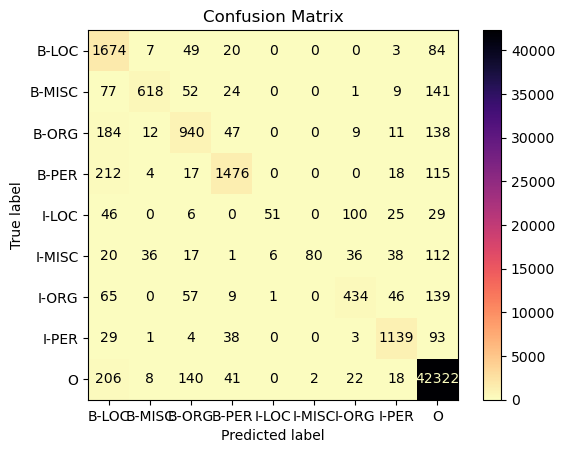

              precision    recall  f1-score   support

       B-LOC      0.666     0.911     0.770      1837
      B-MISC      0.901     0.670     0.769       922
       B-ORG      0.733     0.701     0.717      1341
       B-PER      0.891     0.801     0.844      1842
       I-LOC      0.879     0.198     0.324       257
      I-MISC      0.976     0.231     0.374       346
       I-ORG      0.717     0.578     0.640       751
       I-PER      0.871     0.871     0.871      1307
           O      0.980     0.990     0.985     42759

    accuracy                          0.949     51362
   macro avg      0.846     0.661     0.699     51362
weighted avg      0.951     0.949     0.946     51362



In [58]:
print(utils.metrics_and_matrix('nb_file.conll'))

In [136]:
#SVM. Note that running this cell will trigger a Grid search and will take some time to finish.
svc_model, svc_vec = create_classifier(train_file=train_file, model_name = 'SVC')
classify_data('../../data/conll2003/conll2003.dev.conll', 'svm_file.conll', model=svc_model, vec=svc_vec)

C:\Users\melou\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\melou\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\melou\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\melou\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\melou\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\melou\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number 

Best value of C: 1
Best value of loss: squared_hinge
Best value of max_iter: 2000


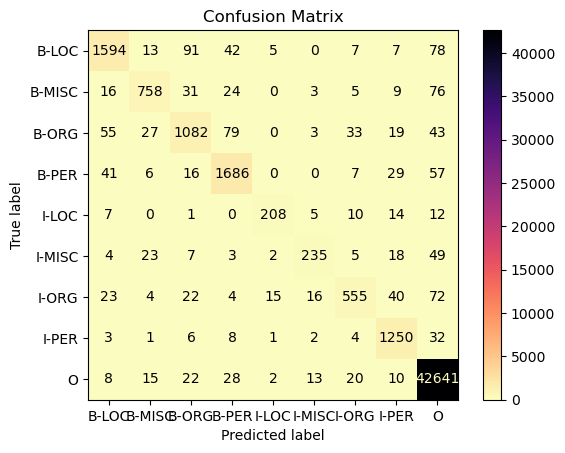

              precision    recall  f1-score   support

       B-LOC      0.910     0.868     0.889      1837
      B-MISC      0.895     0.822     0.857       922
       B-ORG      0.847     0.807     0.826      1341
       B-PER      0.900     0.915     0.907      1842
       I-LOC      0.893     0.809     0.849       257
      I-MISC      0.848     0.679     0.754       346
       I-ORG      0.859     0.739     0.795       751
       I-PER      0.895     0.956     0.925      1307
           O      0.990     0.997     0.994     42759

    accuracy                          0.974     51362
   macro avg      0.893     0.844     0.866     51362
weighted avg      0.973     0.974     0.973     51362



In [160]:
print(utils.metrics_and_matrix('svm_file.conll'))

## Feature ablation

In [81]:
from itertools import combinations

def feature_ablation(train_file, dev_file, all_features):
    """
    Performs feature ablation to identify the best subset of features for a classification task. 
    This function tests all possible subsets of features to identify the combination that maximizes the F1 score 
    on the development dataset.

    Parameters:
        train_file (str): Path to the training dataset file.
        dev_file (str): Path to the development (validation) dataset file.
        all_features (list of str): List of all available feature names.

    Returns:
        tuple: A tuple containing the highest F1 score (float) and the best subset of features (list of str).
    """
    
    score = 0
    feat = []
    
    for r in range(1, len(all_features) + 1):
        for selected_features in combinations(all_features, r):

            selected_features = list(selected_features)
            
            print(f"\033[1mTesting features: {selected_features}\033[0m")

            train_features = extract_features(train_file)
            dev_features = extract_features(dev_file)
            
            train_features = [
                {feature: feature_dict[feature] for feature in selected_features if feature in feature_dict}
                for feature_dict in train_features
            ]
            dev_features = [
                {feature: feature_dict[feature] for feature in selected_features if feature in feature_dict}
                for feature_dict in dev_features
            ]

            # Just need the below code to extract labels, use whatever function you want for that
            train_data = extract_dict_with_gold(train_file)
            train_labels = [dic['gold_label'] for dic in train_data]
            dev_data = extract_dict_with_gold(dev_file)
            dev_labels = [dic['gold_label'] for dic in dev_data]
            
            vec = DictVectorizer()

            train_features = vec.fit_transform(train_features)
            dev_features = vec.transform(dev_features)

            # Modify which model you want to use here
            model = LogisticRegression(max_iter=1000)
            model.fit(train_features, train_labels)
            
            predictions = model.predict(dev_features)

            f1 = sklearn.metrics.f1_score(dev_labels, predictions, average='macro', zero_division=0)

            print(f1)
            if f1> score:
                score = f1
                feat = selected_features

    return score,feat

score,features = feature_ablation('all_train.conll', 'all_dev.conll', all_features)

Testing features: ['token']
0.6384724422811484
Testing features: ['pos']
0.1527490383508401
Testing features: ['syntax']
0.10095515347265754
Testing features: ['capitalization']
0.10095515347265754
Testing features: ['prev_token']
0.3873612476016032
Testing features: ['next_token']
0.2890638857916428
Testing features: ['token', 'pos']
0.68794678506035
Testing features: ['token', 'syntax']
0.6766428554101426
Testing features: ['token', 'capitalization']
0.691155467363854
Testing features: ['token', 'prev_token']
0.762892596553128
Testing features: ['token', 'next_token']
0.7024746826909516
Testing features: ['pos', 'syntax']
0.22056748680105867
Testing features: ['pos', 'capitalization']
0.21474952069982983
Testing features: ['pos', 'prev_token']
0.5751312678308599
Testing features: ['pos', 'next_token']
0.4398702930409709
Testing features: ['syntax', 'capitalization']
0.15651788028461405
Testing features: ['syntax', 'prev_token']
0.436998341139769
Testing features: ['syntax', 'next_tok

In [162]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import f1_score

def test_feature_combinations(train_file, dev_file, feature_combinations, model, embedded=False, word_embedding_model=None):
    """
    Test predefined feature combinations with a specified model.

    Parameters:
        train_file: Path to the training data file.
        dev_file: Path to the development data file.
        feature_combinations: List of feature combinations to test.
        model: The classifier to use (e.g., LinearSVC).
        embedded: Whether to use word embeddings for feature extraction.
        word_embedding_model: The word embedding model to use if `embedded` is True.

    Returns:
        Best F1 score and the corresponding feature combination.
    """
    best_score = 0
    best_features = []

    for selected_features in feature_combinations:
        print(f"\033[1mTesting features: {selected_features}\033[0m")

        if embedded:
            print("Extracting features for classification with embeddings...")
            # Extract features and labels with embeddings
            train_data = extract_traditional_features_and_embeddings_plus_gold_labels(
                train_file, word_embedding_model, selected_features=selected_features
            )
            dev_data = extract_traditional_features_and_embeddings_plus_gold_labels(
                dev_file, word_embedding_model, vectorizer=train_data[1], selected_features=selected_features
            )
            
            train_features, _, train_labels = train_data
            dev_features, _, dev_labels = dev_data

        else:
            print("Extracting traditional features...")
            # Traditional feature extraction (unchanged from earlier)
            train_features = extract_features(train_file)
            dev_features = extract_features(dev_file)

            # Filter features based on the current combination
            train_features = [
                {feature: feature_dict[feature] for feature in selected_features if feature in feature_dict}
                for feature_dict in train_features
            ]
            dev_features = [
                {feature: feature_dict[feature] for feature in selected_features if feature in feature_dict}
                for feature_dict in dev_features
            ]

            # Extract labels
            train_data = extract_dict_with_gold(train_file)
            train_labels = [dic['gold_label'] for dic in train_data]
            dev_data = extract_dict_with_gold(dev_file)
            dev_labels = [dic['gold_label'] for dic in dev_data]

            # Vectorize features
            vec = DictVectorizer()
            train_features = vec.fit_transform(train_features)
            dev_features = vec.transform(dev_features)

        # Train and evaluate the model
        print("Training the model...")
        model.fit(train_features, train_labels)
        print("Making predictions...")
        predictions = model.predict(dev_features)

        # Compute F1 score
        f1 = f1_score(dev_labels, predictions, average='macro', zero_division=0)
        print(f"F1 Score: {f1}")

        # Update the best score and features
        if f1 > best_score:
            best_score = f1
            best_features = selected_features

    return best_score, best_features

nbscore, nbfeatures = feature_ablation('all_train.conll', 'all_dev.conll', all_features)

In [164]:
# Define your predefined feature combinations
feature_combinations = [
    ['token', 'pos', 'syntax', 'capitalization', 'prev_token', 'next_token'],
    ['token', 'syntax', 'capitalization', 'prev_token', 'next_token'],
    ['token', 'pos', 'capitalization', 'prev_token', 'next_token'],
    ['token', 'pos', 'syntax', 'prev_token', 'next_token'],
    ['token', 'pos', 'syntax', 'capitalization', 'prev_token'],
    ['token', 'syntax', 'prev_token', 'next_token'],
    ['token', 'syntax', 'capitalization', 'prev_token'],
    ['token', 'pos', 'capitalization', 'prev_token'],
    ['token', 'capitalization', 'prev_token', 'next_token'],
    ['token', 'capitalization', 'prev_token'],
]

# Test with Multinomial Naive Bayes
nb_best_score, nb_best_features = test_feature_combinations(
    'all_train.conll', 'all_dev.conll', feature_combinations, nb_model
)

print(f"Best features: {nb_best_features} with F1 score: {nb_best_score}")


Testing features: ['token', 'pos', 'syntax', 'capitalization', 'prev_token', 'next_token']
Extracting traditional features...
Training the model...
Making predictions...
F1 Score: 0.6907864290481156
Testing features: ['token', 'syntax', 'capitalization', 'prev_token', 'next_token']
Extracting traditional features...
Training the model...
Making predictions...
F1 Score: 0.704850685871382
Testing features: ['token', 'pos', 'capitalization', 'prev_token', 'next_token']
Extracting traditional features...
Training the model...
Making predictions...
F1 Score: 0.6923176424092728
Testing features: ['token', 'pos', 'syntax', 'prev_token', 'next_token']
Extracting traditional features...
Training the model...
Making predictions...
F1 Score: 0.6986065941666284
Testing features: ['token', 'pos', 'syntax', 'capitalization', 'prev_token']
Extracting traditional features...
Training the model...
Making predictions...
F1 Score: 0.6881748151630929
Testing features: ['token', 'syntax', 'prev_token', 'ne

In [165]:
svc_best_score, svc_best_features = test_feature_combinations(
    'all_train.conll', 'all_dev.conll', feature_combinations, model
)

print(f"Best features: {svc_best_features} with F1 score: {svc_best_score}")

Testing features: ['token', 'pos', 'syntax', 'capitalization', 'prev_token', 'next_token']
Extracting traditional features...
Training the model...
Making predictions...
F1 Score: 0.8668499197051349
Testing features: ['token', 'syntax', 'capitalization', 'prev_token', 'next_token']
Extracting traditional features...
Training the model...
Making predictions...
F1 Score: 0.8662641921017029
Testing features: ['token', 'pos', 'capitalization', 'prev_token', 'next_token']
Extracting traditional features...
Training the model...
Making predictions...
F1 Score: 0.8659996219841898
Testing features: ['token', 'pos', 'syntax', 'prev_token', 'next_token']
Extracting traditional features...
Training the model...
Making predictions...
F1 Score: 0.8591858391370751
Testing features: ['token', 'pos', 'syntax', 'capitalization', 'prev_token']
Extracting traditional features...
Training the model...
Making predictions...
F1 Score: 0.8381370122893024
Testing features: ['token', 'syntax', 'prev_token', 'n

In [168]:
def error_analysis(output_gold_pred_file):
    """
    Analyzes errors in classification by comparing the gold labels with the predicted labels 
    from a file containing the classification results.

    Parameters:
        output_gold_pred_file (str): Path to the file containing the tokens, gold labels, and predicted labels.
        The first column should be the token, the second to last column should be the gold label, and the last
        column should be the predicted label.

    Returns: a list of strings containing the cases where the gold label does not match the predicted label.
    """
    all_errors = []
    with open(output_gold_pred_file, 'r', encoding='utf8') as infile:
            lines = infile.readlines()
            for line_index, line in enumerate(lines):
                components = line.rstrip('\n').split()
                if len(components) > 0:
                    token = components[0]
                    gold_label = components[-2]
                    prediction = components[-1]
                    if gold_label != prediction:
                        all_errors.append(f'{token}: {gold_label}, {prediction}')
    return all_errors

In [170]:
print('SVM error analysis')
error_analysis('svm_file.conll')

SVM error analysis


['West: B-MISC, B-LOC',
 'Indian: I-MISC, I-LOC',
 'Somerset: B-ORG, I-PER',
 'Such: B-PER, O',
 'the: O, B-LOC',
 'Oval: B-LOC, I-LOC',
 'ex-England: B-MISC, O',
 '197-8: O, I-PER',
 'Moody: I-PER, B-ORG',
 '6-82: O, I-ORG',
 'ASHES: B-MISC, O',
 'Ashes: B-MISC, B-ORG',
 'and: I-ORG, O',
 'British: B-ORG, B-MISC',
 'Counties: I-ORG, I-PER',
 'Tour: O, B-MISC',
 'of: I-ORG, O',
 'Norfolk: I-ORG, B-LOC',
 "'s: I-ORG, O",
 'XI: I-ORG, B-ORG',
 'First: O, B-MISC',
 'Surrey: B-ORG, I-PER',
 'Manchester: B-LOC, B-ORG',
 'Counties: I-ORG, B-ORG',
 'Fourth: O, I-PER',
 'Fifth: O, I-PER',
 'Sixth: O, I-PER',
 'ENGLAND: B-LOC, O',
 'Platt: B-PER, B-LOC',
 'Teddy: B-PER, I-PER',
 'BELGRADE: B-LOC, O',
 'LITHUANIA: B-LOC, B-ORG',
 'BUCHAREST: B-LOC, O',
 'ROTOR: B-ORG, O',
 'LOCKED: O, B-ORG',
 'VOLGOGRAD: B-LOC, O',
 'MOSCOW: B-LOC, O',
 'PANAMA: B-LOC, B-PER',
 'ROBERTO: B-PER, O',
 'DURAN: I-PER, O',
 'THE: O, B-ORG',
 'PANAMA: B-LOC, B-ORG',
 'Panamanian: B-MISC, O',
 '": I-PER, O',
 'Hands: 

## Error analysis

Total lowercase named entities: 122
Correctly classified named entities: 60
Incorrectly classified named entities: 62

Correct classifications:
Token: 's, Gold Label: I-LOC, Predicted Label: I-LOC
Token: 's, Gold Label: I-LOC, Predicted Label: I-LOC
Token: 's, Gold Label: I-LOC, Predicted Label: I-LOC
Token: of, Gold Label: I-MISC, Predicted Label: I-MISC
Token: of, Gold Label: I-MISC, Predicted Label: I-MISC
Token: serie, Gold Label: B-MISC, Predicted Label: B-MISC
Token: de, Gold Label: B-PER, Predicted Label: B-PER
Token: de, Gold Label: I-PER, Predicted Label: I-PER
Token: de, Gold Label: I-PER, Predicted Label: I-PER
Token: of, Gold Label: I-ORG, Predicted Label: I-ORG
Token: of, Gold Label: I-ORG, Predicted Label: I-ORG
Token: of, Gold Label: I-ORG, Predicted Label: I-ORG
Token: interior, Gold Label: B-ORG, Predicted Label: B-ORG
Token: ministry, Gold Label: I-ORG, Predicted Label: I-ORG
Token: of, Gold Label: I-ORG, Predicted Label: I-ORG
Token: of, Gold Label: I-ORG, Predicted 

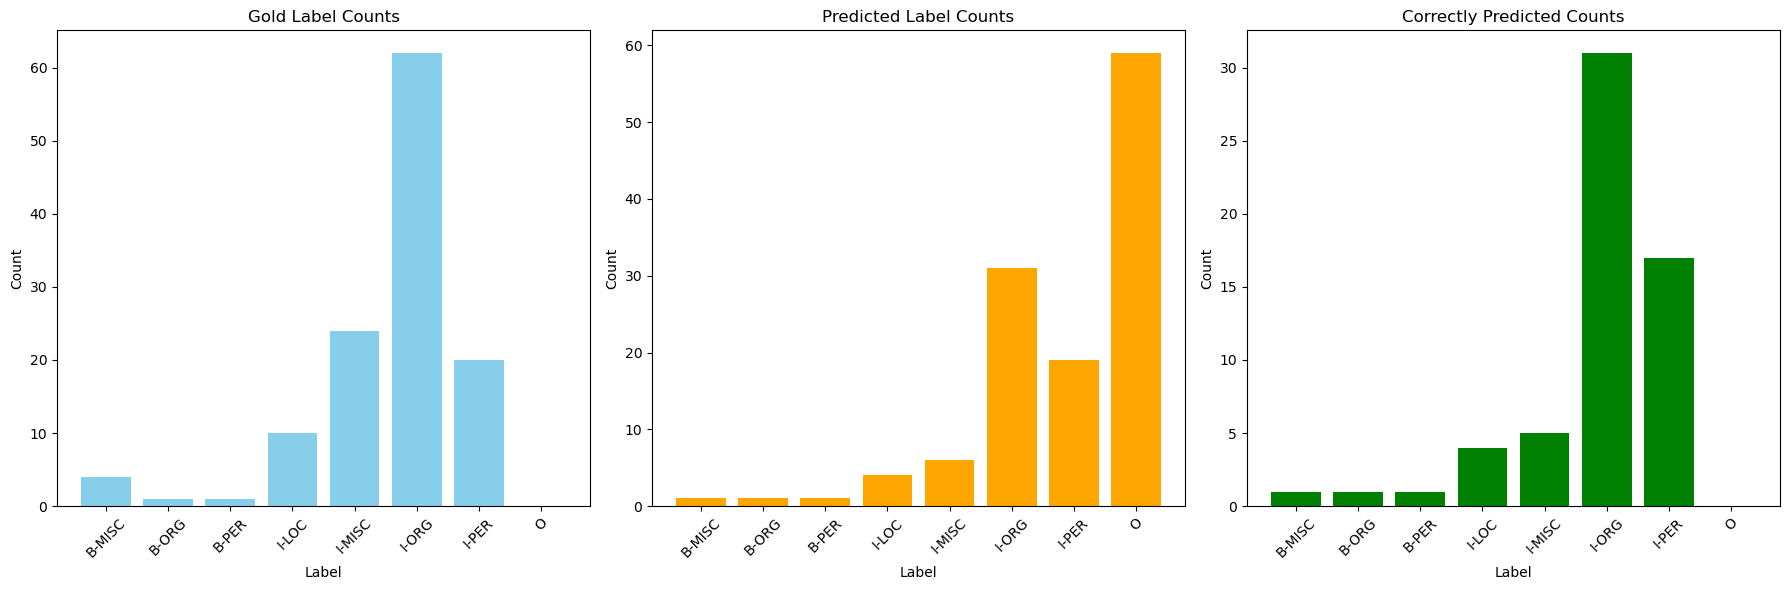

In [143]:
def analyze_lowercase_classification(conll_file_path):
    """
    Takes the path to a conll file with five columns (last column is the predicted label and second to last is gold).
    Finds lowercase named entities and separates them into correctly and incorrectly classified.
    Prints number of total lowercase named entities and out of those entities it prints two lists (correcly and incorrectly classified).
    Prints charts with gold, predicted, and correctly predicted label counts. 
    """
    total_instances = 0
    correct_instances = 0
    correct_classifications = []
    wrong_classifications = []

    label_stats = {"gold": {}, "predicted": {}, "correct": {}}

    with open(conll_file_path, 'r', encoding='utf-8') as file:
        for line in file:
            if not line.strip():
                continue
            columns = line.strip().split()
            token, pos, chunk, gold_label, predicted_label = columns
            if token.islower() and gold_label != 'O':
                total_instances += 1
                label_stats["gold"][gold_label] = label_stats["gold"].get(gold_label, 0) + 1
                label_stats["predicted"][predicted_label] = label_stats["predicted"].get(predicted_label, 0) + 1
                if gold_label == predicted_label:
                    correct_instances += 1
                    correct_classifications.append((token, gold_label, predicted_label))
                    label_stats["correct"][gold_label] = label_stats["correct"].get(gold_label, 0) + 1
                else:
                    wrong_classifications.append((token, gold_label, predicted_label))

    print(f"Total lowercase named entities: {total_instances}")
    print(f"Correctly classified named entities: {correct_instances}")
    print(f"Incorrectly classified named entities: {len(wrong_classifications)}")

    print("\nCorrect classifications:")
    for token, gold, predicted in correct_classifications:
        print(f"Token: {token}, Gold Label: {gold}, Predicted Label: {predicted}")

    print("\nWrong classifications:")
    for token, gold, predicted in wrong_classifications:
        print(f"Token: {token}, Gold Label: {gold}, Predicted Label: {predicted}")

    print("\nLabel Statistics for Lowercase Entities:")
    print("Gold Label Counts:")
    for label, count in label_stats["gold"].items():
        print(f"  {label}: {count}")

    print("\nPredicted Label Counts:")
    for label, count in label_stats["predicted"].items():
        print(f"  {label}: {count}")

    print("\nCorrectly Predicted Counts:")
    for label, count in label_stats["correct"].items():
        print(f"  {label}: {count}")

    all_labels = set(label_stats["gold"].keys()).union(
        label_stats["predicted"].keys(), label_stats["correct"].keys())
    sorted_labels = sorted(all_labels)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    gold_counts = [label_stats["gold"].get(label, 0) for label in sorted_labels]
    axes[0].bar(sorted_labels, gold_counts, color='skyblue')
    axes[0].set_title('Gold Label Counts')
    axes[0].set_xlabel('Label')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    predicted_counts = [label_stats["predicted"].get(label, 0) for label in sorted_labels]
    axes[1].bar(sorted_labels, predicted_counts, color='orange')
    axes[1].set_title('Predicted Label Counts')
    axes[1].set_xlabel('Label')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

    correct_counts = [label_stats["correct"].get(label, 0) for label in sorted_labels]
    axes[2].bar(sorted_labels, correct_counts, color='green')
    axes[2].set_title('Correctly Predicted Counts')
    axes[2].set_xlabel('Label')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

analyze_lowercase_classification('svm_file.conll')